Saved abyssal_bloom.png


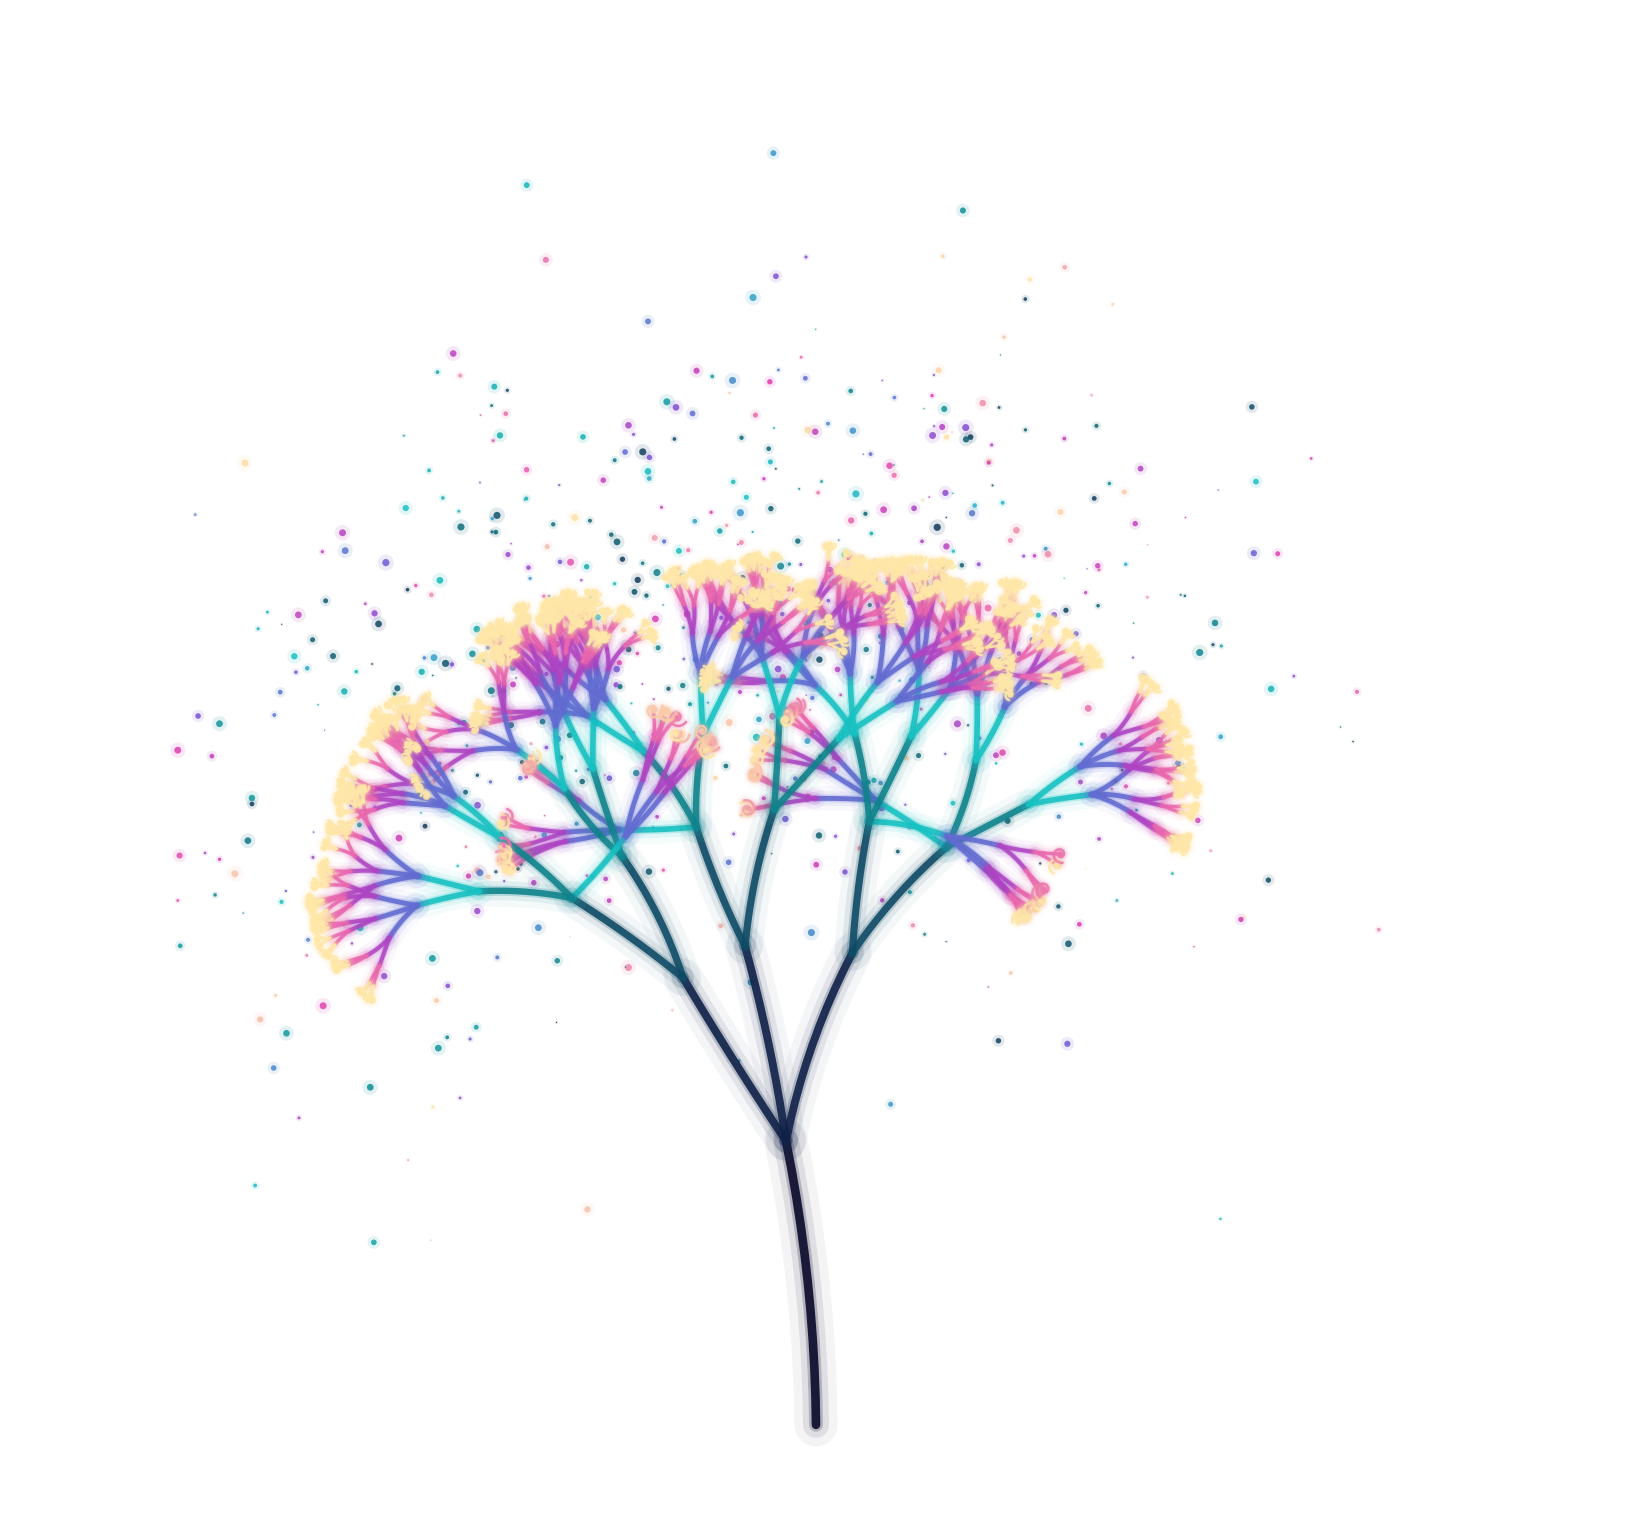

In [1]:
"""
ABYSSAL BLOOM
=============
A generative fractal artwork inspired by deep-sea bioluminescent siphonophores
and branching coral colonies.

--------------------------------------------------------------------------
MATHEMATICAL / FRACTAL CONCEPT (read this before the code)
--------------------------------------------------------------------------
The artwork is built from a single recursive growth function, `grow()`.
Each call to `grow()`:

  1. Draws one curved "limb" (a short polyline whose heading drifts by a
     random curvature so it looks organic rather than ruler-straight).
  2. Stops if it has run out of recursion depth ("energy"), in which case
     it terminates in a small logarithmic-spiral "polyp" bulb
     (r = a * e^(b*theta) -- the same curve that describes nautilus shells,
     ram's horns and many mollusc structures).
  3. Otherwise it spawns 2-3 child limbs at new angles, each with:
         length_child = length_parent * RATIO   (RATIO ≈ 0.68, constant)
         depth_child  = depth_parent - 1
     Because every child is an exact geometric copy of the *function that
     drew its parent*, only scaled down by a constant ratio and rotated,
     the whole structure is statistically self-similar across scales --
     this is the defining property of a fractal branching system (the same
     idea that underlies real botanical/coral growth models such as
     Lindenmayer systems, but here the branching angles, curvature and
     bud placement are custom-designed rather than a textbook L-system).
  4. A handful of branches, chosen at a fixed mid-level of recursion,
     additionally spawn an entire *second, smaller copy of the whole
     colony* ("buds"). This is what gives the piece secondary structures
     of varying scale around the main colony, echoing how real coral and
     siphonophore colonies bud new sub-colonies off an established branch.

So self-similarity comes from two places at once:
  * Vertical self-similarity: every sub-branch is a scaled, rotated replay
    of its parent branch (the recursive call itself).
  * Compositional self-similarity: the whole "colony" shape (stem + fan of
    branches + terminal polyps) reappears in miniature as buds elsewhere
    in the image, at a different scale and orientation.

Colour is mapped purely to the recursion generation number (how many
branchings a segment is removed from the root) and to a small amount of
radial falloff, producing smooth gradients that make deeper generations
glow brighter/cooler, mimicking bioluminescence concentrating toward the
newest growth tips.

Everything you see -- every curve, spiral, and point of light -- is the
direct output of this recursive geometry. No image is loaded, traced or
generated by an external model; only numpy trigonometry, recursion, and
matplotlib rendering are used.
--------------------------------------------------------------------------
"""

import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import LinearSegmentedColormap

# --------------------------------------------------------------------------
# REPRODUCIBILITY
# --------------------------------------------------------------------------
SEED = 42
rng = np.random.default_rng(SEED)

# --------------------------------------------------------------------------
# TUNABLE PARAMETERS  (change these to explore variations)
# --------------------------------------------------------------------------
MAX_DEPTH       = 8          # recursion depth of the main colony (structure detail)
BUD_DEPTH       = 3          # recursion depth given to smaller "bud" colonies
BRANCH_RATIO    = 0.685      # how much shorter each child branch is than its parent
BASE_LENGTH     = 150.0      # length of the very first (root) limb
CURVATURE_DEG   = 20.0       # max random heading-drift per limb, in degrees
SPREAD_DEG      = 25.0       # base angular spread between sibling branches
TRIFURCATE_EVERY = 4         # every Nth generation gets 3 children instead of 2
N_PARTICLES     = 650        # loose bioluminescent "plankton" points scattered around
IMG_SIZE_PX     = 1600       # output resolution (square canvas)
FIGSIZE_IN      = 10         # matplotlib figure size in inches (resolution = size*dpi)
DPI             = IMG_SIZE_PX / FIGSIZE_IN
OUTPUT_FILE     = "abyssal_bloom.png"

# --------------------------------------------------------------------------
# COLOUR PALETTE
# A hand-chosen bioluminescent palette: deep indigo roots, rising through
# teal and cyan, into violet and magenta, flaring to pale gold at the very
# newest growth tips -- evoking light produced by living tissue in the deep
# ocean. Built as a smooth matplotlib colormap so every generation gets an
# interpolated colour rather than a flat, banded one.
# --------------------------------------------------------------------------
PALETTE_STOPS = [
    (0.00, "#0a0a2a"),   # near-black indigo (root, oldest growth)
    (0.18, "#132a52"),   # deep abyssal blue
    (0.36, "#0e6e7a"),   # teal
    (0.55, "#17c2c2"),   # bright cyan
    (0.72, "#7a4fd6"),   # violet
    (0.87, "#e13bb0"),   # magenta / hot pink
    (1.00, "#ffe7a8"),   # pale bioluminescent gold (newest tips / polyps)
]
bloom_cmap = LinearSegmentedColormap.from_list(
    "abyssal_bloom", [c for _, c in PALETTE_STOPS], N=512
)


def generation_color(generation, max_generation, jitter=0.0):
    """Map a branch's recursion generation to a colour along the palette.
    A small optional jitter adds hue variety among same-generation tips
    (e.g. polyps), so the canopy isn't a single flat colour."""
    t = np.clip(generation / max(max_generation, 1) + jitter, 0.0, 1.0)
    return bloom_cmap(t)


# --------------------------------------------------------------------------
# GEOMETRY HELPERS
# --------------------------------------------------------------------------
def curved_polyline(x0, y0, angle_deg, length, curvature_deg, steps=10):
    """
    Build one organic limb as a short polyline whose heading drifts
    smoothly (not randomly per-step, but via one drawn curvature value)
    so branches read as gently bending, living tissue rather than straight
    mechanical sticks.
    Returns: list of (x, y) points, and the final (x, y, heading).
    """
    curvature = rng.uniform(-curvature_deg, curvature_deg)
    pts = [(x0, y0)]
    x, y, heading = x0, y0, angle_deg
    step_len = length / steps
    for _ in range(steps):
        heading += curvature / steps
        rad = math.radians(heading)
        x += step_len * math.cos(rad)
        y += step_len * math.sin(rad)
        pts.append((x, y))
    return pts, (x, y, heading)


def log_spiral_points(cx, cy, start_angle_deg, size, turns=1.8, n=60):
    """
    A logarithmic spiral: r = a * e^(b*theta).
    This single equation describes the growth of nautilus shells, ram
    horns and many mollusc/coral micro-structures -- used here as the
    terminal "polyp" bulb that caps every branch tip.
    """
    a = size * 0.06
    b = 0.18
    theta = np.linspace(0, turns * 2 * math.pi, n)
    r = a * np.exp(b * theta)
    ang = np.radians(start_angle_deg) + theta
    xs = cx + r * np.cos(ang)
    ys = cy + r * np.sin(ang)
    return xs, ys


# --------------------------------------------------------------------------
# RECURSIVE COLONY GROWTH
# --------------------------------------------------------------------------
# Each element appended to `segments` is a dict:
#   {'pts': [(x,y), ...], 'generation': int, 'kind': 'limb'|'polyp'}
segments = []
polyps = []          # (cx, cy, angle, size, generation) for terminal bulbs
particle_seeds = []  # tip locations used later to seed floating light particles


def grow(x, y, angle, length, depth, generation, allow_buds, max_gen_ref):
    """The single recursive function that generates the whole structure."""
    if length < 2.0 or depth < 0:
        return

    pts, (ex, ey, eheading) = curved_polyline(x, y, angle, length, CURVATURE_DEG)
    segments.append({'pts': pts, 'generation': generation, 'kind': 'limb'})
    max_gen_ref[0] = max(max_gen_ref[0], generation)

    if depth == 0:
        # Terminal growth tip -> cap it with a logarithmic-spiral polyp.
        size = max(length * 0.75, 5.0)
        polyps.append((ex, ey, eheading, size, generation + 1))
        particle_seeds.append((ex, ey))
        return

    # Occasionally spawn an entire smaller *copy of the whole colony*
    # ("budding"), giving the composition secondary structures at a
    # different scale -- mirrors how real coral/siphonophore colonies
    # propagate by budding new sub-colonies off an established branch.
    if allow_buds and depth == MAX_DEPTH - 2 and rng.random() < 0.65:
        bud_angle = eheading + rng.choice([-1, 1]) * rng.uniform(60, 105)
        grow(ex, ey, bud_angle, length * 0.6, BUD_DEPTH,
             generation + 2, allow_buds=False, max_gen_ref=max_gen_ref)

    # Number of children: mostly 2 (binary branching), occasionally 3
    # (trifurcation) for natural irregularity, avoiding a mechanically
    # uniform look.
    n_children = 3 if generation % TRIFURCATE_EVERY == 0 else 2
    spread = SPREAD_DEG + 8.0 * math.sin(generation * 0.9)
    asym = rng.uniform(-6, 6)  # per-branch asymmetric bias, breaks mirror symmetry

    for i in range(n_children):
        offset = (i - (n_children - 1) / 2.0) * spread + rng.uniform(-6, 6) + asym
        child_angle = eheading + offset
        child_length = length * (BRANCH_RATIO + rng.uniform(-0.04, 0.04))
        grow(ex, ey, child_angle, child_length, depth - 1,
             generation + 1, allow_buds, max_gen_ref)


# Grow the main colony upward from the bottom of the canvas.
max_generation_holder = [0]
grow(0.0, -260.0, 90.0, BASE_LENGTH, MAX_DEPTH, 0,
     allow_buds=True, max_gen_ref=max_generation_holder)
MAX_GEN = max_generation_holder[0]

# --------------------------------------------------------------------------
# FIGURE SETUP
# --------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(FIGSIZE_IN, FIGSIZE_IN), dpi=DPI)
ax.set_facecolor("none")
fig.patch.set_facecolor("none")


def draw_glow_line(pts, color, base_lw, zorder):
    """Simulate bioluminescent glow by stacking the same stroke multiple
    times with decreasing opacity and increasing width."""
    xs = [p[0] for p in pts]
    ys = [p[1] for p in pts]
    for lw_mult, alpha in ((5.0, 0.045), (3.0, 0.09), (1.6, 0.22), (1.0, 0.9)):
        ax.plot(xs, ys, color=color, linewidth=base_lw * lw_mult, alpha=alpha,
                 solid_capstyle="round", zorder=zorder)


# --------------------------------------------------------------------------
# DRAW LIMBS  (coloured + width-scaled by generation: older = thicker/dimmer,
# newer = thinner/brighter, echoing real growth thickening near the base)
# --------------------------------------------------------------------------
for seg in segments:
    gen = seg['generation']
    color = generation_color(gen, MAX_GEN)
    lw = max(0.4, 3.4 * (1.0 - gen / (MAX_GEN + 2)) + 0.5)
    draw_glow_line(seg['pts'], color, lw, zorder=2)

# --------------------------------------------------------------------------
# DRAW TERMINAL POLYPS (logarithmic-spiral bulbs at every branch tip)
# --------------------------------------------------------------------------
for (cx, cy, ang, size, gen) in polyps:
    hue_jitter = rng.uniform(-0.12, 0.06)
    color = generation_color(gen, MAX_GEN, jitter=hue_jitter)
    xs, ys = log_spiral_points(cx, cy, ang, size)
    draw_glow_line(list(zip(xs, ys)), color, 1.1, zorder=3)
    # small radiant core at the polyp centre
    for r, a in ((size * 0.34, 0.08), (size * 0.20, 0.18), (size * 0.09, 0.85)):
        ax.add_patch(patches.Circle((cx, cy), r, color=color, alpha=a, zorder=4, lw=0))

# --------------------------------------------------------------------------
# FLOATING BIOLUMINESCENT PARTICLES
# Scattered near growth tips (with extra jitter) to suggest plankton /
# drifting light in the surrounding water -- reinforcing negative space
# around the central colony rather than filling the whole canvas.
# --------------------------------------------------------------------------
if particle_seeds:
    seed_arr = np.array(particle_seeds)
    idx = rng.integers(0, len(seed_arr), size=N_PARTICLES)
    jitter = rng.normal(0, 55, size=(N_PARTICLES, 2))
    px = seed_arr[idx, 0] + jitter[:, 0]
    py = seed_arr[idx, 1] + jitter[:, 1] * 1.3
else:
    px = rng.uniform(-380, 380, N_PARTICLES)
    py = rng.uniform(-260, 440, N_PARTICLES)

particle_t = rng.random(N_PARTICLES)
particle_colors = bloom_cmap(np.clip(particle_t * 0.8 + 0.2, 0, 1))
particle_sizes = rng.uniform(0.6, 6.0, N_PARTICLES) ** 1.6

ax.scatter(px, py, s=particle_sizes * 3.0, c=particle_colors, alpha=0.12,
           linewidths=0, zorder=1)
ax.scatter(px, py, s=particle_sizes * 0.6, c=particle_colors, alpha=0.85,
           linewidths=0, zorder=1)

# --------------------------------------------------------------------------
# FINAL FRAMING
# --------------------------------------------------------------------------
ax.set_xlim(-420, 420)
ax.set_ylim(-300, 480)
ax.set_aspect("equal")
ax.axis("off")
fig.tight_layout(pad=0)

fig.savefig(OUTPUT_FILE, dpi=DPI, transparent=True, bbox_inches="tight", pad_inches=0.1)
print(f"Saved {OUTPUT_FILE}")

plt.show()